# **Fase exploratória**

In [1]:
import umap
import sys
import os
sys.path.append(os.path.abspath("../../.."))

import pickle
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

from sklearn.manifold import TSNE
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

from sklearn.preprocessing import StandardScaler
from scipy.linalg import LinAlgError

from core.split_samples import get_splited_data

from sklearn.utils import resample

import matplotlib.pyplot as plt

from scipy.stats import f_oneway

#         **Exploratory Analysis**

## **Etapa 1: Análise Inicial e Preparação**

- Dados a Utilizar: DataFrame Total.
- Objetivo Principal: Garantir a saúde, integridade e o entendimento básico dos dados brutos antes de qualquer divisão.


### 1.1 Carregando os dados

In [3]:
data = pd.read_excel('../../../datasets/base_vertical/intermediate/HS_agregado_sem_cod_20windows_normal_abnormal_Binary.xlsx')
data = data.drop(columns=['window_id'])

data.head()

,Heart Sound ID,freq_mean,centro_x_mean,centro_y_mean,raio_medio_mean,raio_std_mean,raio_max_mean,raio_min_mean,simetria_x_mean,simetria_y_mean,...,lpc_8,lpc_9,lpc_10,autocorr_lag_1,autocorr_lag_2,autocorr_lag_3,has_trapping,Gender,Heart Sound Type,Location
0,F_N_A,69.368912,-0.000555,-0.000656,0.071051,0.098246,0.705251,0.000607,0.075598,0.075674,...,1.021818,-0.678406,0.269206,21.280822,11.789467,0.937960,0,F,Normal,Apex
1,F_N_A,66.240986,0.001651,-0.000122,0.071415,0.095641,0.662329,0.000686,0.074235,0.073031,...,1.048368,-0.706707,0.301243,25.982837,15.102910,2.105856,0,F,Normal,Apex
2,F_N_A,62.663246,0.000526,-0.000303,0.067735,0.099042,0.675599,0.000595,0.070298,0.069982,...,1.030822,-0.697949,0.301871,23.597389,13.826223,2.066747,0,F,Normal,Apex
3,F_N_A,62.467448,-0.000309,-0.000558,0.059098,0.085528,0.675312,0.000563,0.059822,0.059571,...,1.020846,-0.694309,0.298544,19.951285,11.401367,1.246206,0,F,Normal,Apex
4,F_N_A,63.516695,-0.000351,0.000035,0.060394,0.091413,0.675342,0.000512,0.065223,0.065217,...,0.987878,-0.652313,0.284066,18.257097,10.265130,0.783888,0,F,Normal,Apex


### 1.2 Inspeção Estrutural
Verificar o número de linhas, colunas, e os tipos de dados de cada coluna. Procurar por colunas que deveriam ser numéricas mas estão como object (texto).

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 100 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Heart Sound ID              980 non-null    object 
 1   freq_mean                   980 non-null    float64
 2   centro_x_mean               980 non-null    float64
 3   centro_y_mean               980 non-null    float64
 4   raio_medio_mean             980 non-null    float64
 5   raio_std_mean               980 non-null    float64
 6   raio_max_mean               980 non-null    float64
 7   raio_min_mean               980 non-null    float64
 8   simetria_x_mean             980 non-null    float64
 9   simetria_y_mean             980 non-null    float64
 10  densidade_nucleo_mean       980 non-null    float64
 11  comprimento_curva_mean      980 non-null    float64
 12  variacao_curvatura_mean     980 non-null    float64
 13  mudanca_media_direcao_mean  980 no

In [5]:
len(data.columns)

100

In [6]:
data.isnull().sum()

Heart Sound ID      0
freq_mean           0
centro_x_mean       0
centro_y_mean       0
raio_medio_mean     0
                   ..
autocorr_lag_3      0
has_trapping        0
Gender              0
Heart Sound Type    0
Location            0
Length: 100, dtype: int64

### 1.3 Análise Descritiva

Calcular estatísticas básicas (média, desvio padrão, mínimo, máximo, quartis) para todas as colunas numéricas. Isso ajuda a identificar escalas muito diferentes entre as features, o que confirma a necessidade de normalização mais tarde.

In [7]:
data.describe()

,freq_mean,centro_x_mean,centro_y_mean,raio_medio_mean,raio_std_mean,raio_max_mean,raio_min_mean,simetria_x_mean,simetria_y_mean,densidade_nucleo_mean,...,lpc_5,lpc_6,lpc_7,lpc_8,lpc_9,lpc_10,autocorr_lag_1,autocorr_lag_2,autocorr_lag_3,has_trapping
count,980.000000,9.800000e+02,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,...,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000
mean,80.272575,2.781231e-05,0.000023,0.055759,0.063659,0.536470,0.000511,0.056128,0.056003,0.833613,...,-1.222401,1.272787,-1.065320,0.903394,-0.570879,0.289220,13.776489,7.293640,2.569582,0.579592
std,35.268374,5.532162e-04,0.000544,0.028939,0.030766,0.260382,0.000286,0.028582,0.028483,0.110204,...,0.475373,0.419846,0.384706,0.302174,0.222503,0.075830,12.733734,9.007789,7.486302,0.493877
min,41.026786,-6.146987e-03,-0.004580,0.009012,0.007763,0.045979,0.000085,0.008751,0.008746,0.435478,...,-3.076415,0.426437,-2.351755,0.244608,-1.188039,0.092426,-2.202234,-6.101485,-16.125463,0.000000
25%,59.638861,-1.717198e-04,-0.000141,0.033988,0.037615,0.323310,0.000283,0.034630,0.034686,0.776611,...,-1.493733,0.933275,-1.327404,0.674419,-0.728168,0.241572,3.346425,1.132912,-0.503281,0.000000
50%,68.044776,-8.623517e-07,0.000015,0.052426,0.062805,0.511643,0.000470,0.053340,0.053373,0.864109,...,-1.169243,1.222875,-1.008863,0.848807,-0.536668,0.294697,11.414176,4.871758,0.690164,1.000000
75%,80.972893,1.752623e-04,0.000189,0.075488,0.086203,0.715322,0.000685,0.075850,0.075701,0.912354,...,-0.863843,1.520309,-0.798485,1.129337,-0.421297,0.343446,20.699525,10.513263,4.439636,1.000000
max,244.020833,5.066647e-03,0.002996,0.155733,0.151345,1.001086,0.001730,0.153127,0.151798,0.989990,...,-0.275841,2.824571,-0.210408,1.774550,-0.099581,0.500930,69.206063,54.894162,39.713240,1.000000


### 1.5 Análise Univariada

#### 1.5.1 Análise das Features Categóricas

<Axes: xlabel='Gender', ylabel='count'>

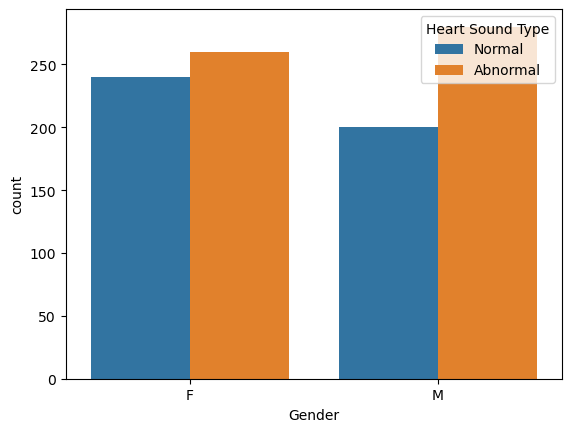

In [8]:
sns.countplot(x='Gender', hue='Heart Sound Type', data=data)

<Axes: xlabel='Heart Sound Type', ylabel='count'>

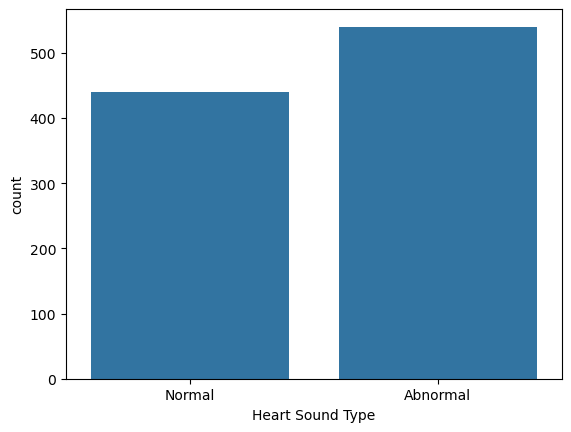

In [9]:
#sns.countplot(x='Location', data=data)
sns.countplot(x='Heart Sound Type', data=data)
#sns.countplot(x='Heart Sound Type', hue='Location', data=data)
#sns.countplot(x='Heart Sound Type', hue='Gender', data=data)

<Axes: xlabel='Location', ylabel='count'>

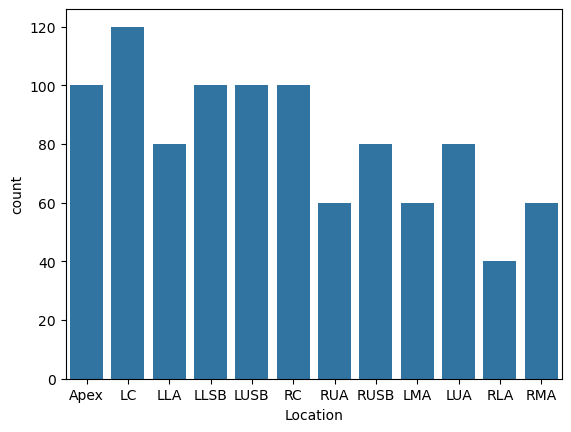

In [10]:
sns.countplot(x='Location', data=data)

<Axes: xlabel='Gender', ylabel='count'>

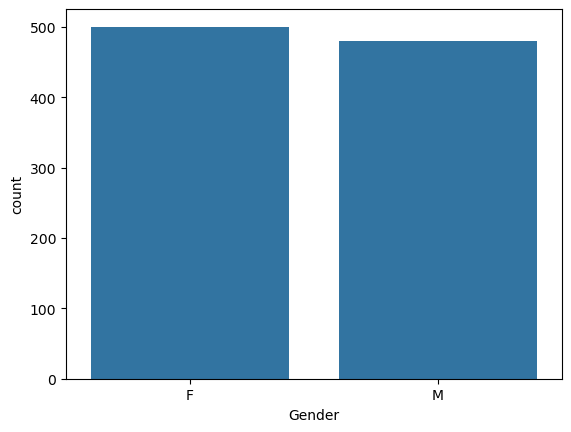

In [11]:
sns.countplot(x='Gender', data=data)

In [12]:
data.value_counts(normalize=True)

Heart Sound ID  freq_mean  centro_x_mean  centro_y_mean  raio_medio_mean  raio_std_mean  raio_max_mean  raio_min_mean  simetria_x_mean  simetria_y_mean  densidade_nucleo_mean  comprimento_curva_mean  variacao_curvatura_mean  mudanca_media_direcao_mean  entropia_raio_mean  auto_intersecoes_mean  rms_energy_mean  spectral_centroid_mean  spectral_rolloff_mean  spectral_bandwidth_mean  spectral_flux_mean  freq_std   centro_x_std  centro_y_std  raio_medio_std  raio_std_std  raio_max_std  raio_min_std  simetria_x_std  simetria_y_std  densidade_nucleo_std  comprimento_curva_std  variacao_curvatura_std  mudanca_media_direcao_std  entropia_raio_std  auto_intersecoes_std  rms_energy_std  spectral_centroid_std  spectral_rolloff_std  spectral_bandwidth_std  spectral_flux_std  mfcc_0       mfcc_1      mfcc_2      mfcc_3     mfcc_4      mfcc_5      mfcc_6      mfcc_7      mfcc_8      mfcc_9      mfcc_10     mfcc_11     mfcc_12     rqa_recurrence_rate  rqa_determinism  rqa_average_diagonal_line  rqa_

<Axes: >

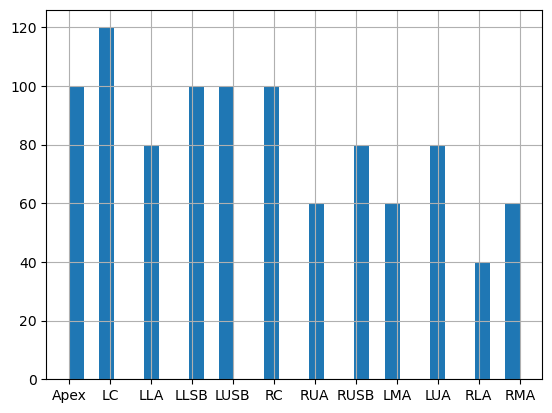

In [13]:
data["Location"].hist(bins=30)

### 1.5 Análise da Variável Alvo

Precisamos verificar a proporção das classes (quantos 'Normais' vs. 'Anormais'). Isso é crucial para saber se  o dataset é desbalanceado.

In [14]:
print(data['Heart Sound Type'].value_counts(normalize=True))


Heart Sound Type
Abnormal    0.55102
Normal      0.44898
Name: proportion, dtype: float64


O dataset multiclasse final foi cuidadosamente balanceado, com 10% de representação para cada uma das 10 classes de sons cardíacos. Isso garante imparcialidade e estabilidade na avaliação dos modelos.

## **Etapa 2: Separação dos Dados** 

Criar as partições de treino e teste, isolando o conjunto de teste para garantir uma avaliação final 100% imparcial.

### 2.1 Definir _features_ (X) e alvo (y)

Aqui precisaremos tomar cuidado com o vazamento de dados por agrupamento (_data leakage due to grouping_). Se uma janela dde um determinado áudio está no treino e outra do mesmo áudio está no teste, o modelo "trapaceia". Ele aprende sobre o determinado áudio no treino e depois é testado em um dado muito similar (outra janela do mesmo áudio), o que leva a uma performance artificialmente alta e a um otimismo irrealista.

Portanto, deve-se pensar em uma divisão baseada em grupos.
A solução é garantir que a unidade de separação não seja a janela (a linha do dataframe), mas sim o áudio de origem (o grupo). Todas as 20 janelas de um determinado áudio devem pertencer juntas ao conjunto de treino ou juntas ao conjunto de teste. Nunca separadas.

O Scikit-learn tem ferramentas específicas para isso. As principais são `GroupShuffleSplit` e `GroupKFold`.

In [15]:
X, y = get_splited_data(data, 'Heart Sound Type')

#### 2.2 Executar a Divisão

In [16]:
groups = X['Heart Sound ID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

"""
O .split() gera os ÍNDICES de treino e teste.
Precisamos usá-lo com next() porque ele é um gerador.
"""
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# usando os índices para criar os df's
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

Verificação: é importante verificar que não há nenhum _Heart Sound ID_ que apareça tanto em `X_train` quanto em `X_test`.

In [17]:
print(f"Audios no treino: {len(X_train['Heart Sound ID'].unique())}")
print(f"Audios no teste: {len(X_test['Heart Sound ID'].unique())}")

train_audios = set(X_train['Heart Sound ID'].unique())
test_audios = set(X_test['Heart Sound ID'].unique())
print("Audios vazados (interseção):", train_audios.intersection(
    test_audios))  # <===== Deve ser um conjunto vazio!

Audios no treino: 39
Audios no teste: 10
Audios vazados (interseção): set()


In [ ]:
# X_test.to_csv('../../../datasets/base_vertical/processed/X_test.csv', index=False)
# X_train.to_csv(
#     '../../../datasets/base_vertical/processed/X_train.csv', index=False)
# y_test.to_csv(
#     '../../../datasets/base_vertical/processed/y_test.csv', index=False)
# y_train.to_csv(
#     '../../../datasets/base_vertical/processed/y_train.csv', index=False)

#### 2.3 Salvando os dados por segurança

In [18]:
X_train = X_train.drop(columns=['Heart Sound ID'])
X_test = X_test.drop(columns=['Heart Sound ID'])

In [19]:

data_to_save = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}
with open('../../../datasets/base_vertical/processed/train_test_sets_normal_vs_sopro.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)


""" 
Para carregar os dados:

with open('../../../datasets/base_vertical/processed/train_test_sets.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

X_train_ = loaded_data['X_train']
X_test_ = loaded_data['X_test']
y_train_ = loaded_data['y_train']
y_test_ = loaded_data['y_test']
"""

" \nPara carregar os dados:\n\nwith open('../../../datasets/base_vertical/processed/train_test_sets.pkl', 'rb') as f:\n    loaded_data = pickle.load(f)\n\nX_train_ = loaded_data['X_train']\nX_test_ = loaded_data['X_test']\ny_train_ = loaded_data['y_train']\ny_test_ = loaded_data['y_test']\n"

##### Mas e quanto aos dados de validação?

Muitas vezes nos perguntamos sobre a separação dos **dados de validação**. 

A Validação Cruzada (Cross-Validation), que implementamos com `StratifiedKFold` e `cross_val_score` / `GridSearchCV`, já cumpre o papel do conjunto de validação de uma forma muito mais sólida e eficiente do que uma separação manual.

Por que precisamos de validação? O conjunto de validação tem dois objetivos principais:

- Ajuste de Hiperparâmetros: Encontrar os melhores parâmetros para um modelo (ex: qual o melhor max_depth para uma árvore de decisão?) sem usar o conjunto de teste.
- Seleção de Modelos: Decidir qual modelo é melhor (ex: Random Forest se sai melhor que MLP?) sem usar o conjunto de teste.

Se usássemos o conjunto de teste para isso, estaríamos "vazando" informação do teste para o nosso processo de decisão, e a avaliação final não seria mais imparcial.

As duas maneiras de se ter um conjunto de validação são:

**Abordagem 1: A Divisão Tripla (Train / Validation / Test)**

Nesta abordagem,  divide-se manualmente seus dados em três partes:
1. Conjunto de Treino (ex: 60%): Usado para treinar o modelo com um conjunto de hiperparâmetros.
2. Conjunto de Validação (ex: 20%): Usado para avaliar o modelo treinado e decidir se os hiperparâmetros são bons. Você repete o treino e a validação até encontrar os melhores parâmetros.
3. Conjunto de Teste (ex: 20%): Usado uma única vez no final, com o modelo final e os melhores hiperparâmetros, para obter a métrica de performance final.

- Quando é usada? Principalmente com datasets muito grandes (milhões de registros), onde treinar o modelo várias vezes (como na validação cruzada) é computacionalmente inviável. É a abordagem padrão em Deep Learning, onde monitora-se a performance no conjunto de validação a cada época de treinamento.

- Desvantagens (especialmente para o seu caso):

     - Desperdício de Dados: Com um dataset de ~1000 registros como o seu, separar 20% para validação significa que você está abrindo mão de 200 amostras que poderiam ser usadas para treinar melhor o seu modelo.
     - Menos Confiável: A performance no conjunto de validação pode depender muito da "sorte" de quais amostras caíram ali. Se, por acaso, algumas amostras difíceis ou fáceis demais caem todas na validação, a estimativa de performance será enviesada.

**Abordagem 2: Divisão Dupla + Validação Cruzada (A que será usada neste projeto)**     

Faz-se apenas uma divisão:

- Conjunto de Treino (ex: 80%): Este é o o universo de trabalho.
- Conjunto de Teste (ex: 20%): Fica trancado até o final.

E onde entra a validação? Ela acontece dinamicamente dentro do conjunto de treino. É exatamente isso que o `StratifiedKFold` faz.

A Validação Cruzada de 5 folds (K=5) funciona da seguinte forma:

Ela pega o `X_train` e o divide em 5 pedaços (folds).
- Rodada 1: Treina o modelo nos pedaços 2, 3, 4 e 5. Usa o pedaço 1 como validação.
- Rodada 2: Treina o modelo nos pedaços 1, 3, 4 e 5. Usa o pedaço 2 como validação.
- Rodada 3: Treina o modelo nos pedaços 1, 2, 4 e 5. Usa o pedaço 3 como validação.
...e assim por diante.

O `cross_val_score` ou `GridSearchCV` faz tudo isso automaticamente. A performance final da validação é a média das performances em cada uma das 5 rodadas.

Quando é usada? É o padrão-ouro para a maioria dos projetos de Machine Learning, especialmente com datasets que não são gigantescos (de centenas até centenas de milhares de registros).

- Vantagens:

     - Uso Eficiente dos Dados: Todas as amostras do conjunto de treino são usadas tanto para treinar quanto para validar em algum momento. Nada é desperdiçado.
     - Muito Mais performática: Como a performance é a média de várias rodadas, o resultado é muito mais estável e confiável do que uma única divisão de validação.

## **Etapa 3: Análise Exploratória Profunda (EDA)**

Dados a utilizar: `X_train` e `y_train`
Aqui deve-se investigar as relações entre asfeatures e a variável alvo para gerar hipóteses e guiar a modelagem.

### 3.1 Análise de Correlação entre as _features_:
- Criar uma matriz de correlação para ver quais _features_ estão fortemente relacionadas entre si. _Features_ com correlação muito alta (ex: >0.9 ou < -0.9>) são redundantes e pode-se considerar remover uma delas.
- Ferramenta: `X_train.corr()`, `seaborn.heatmap(X_train.corr())`

In [20]:
X_train_numeric = X_train.select_dtypes(include='number')

<Axes: >

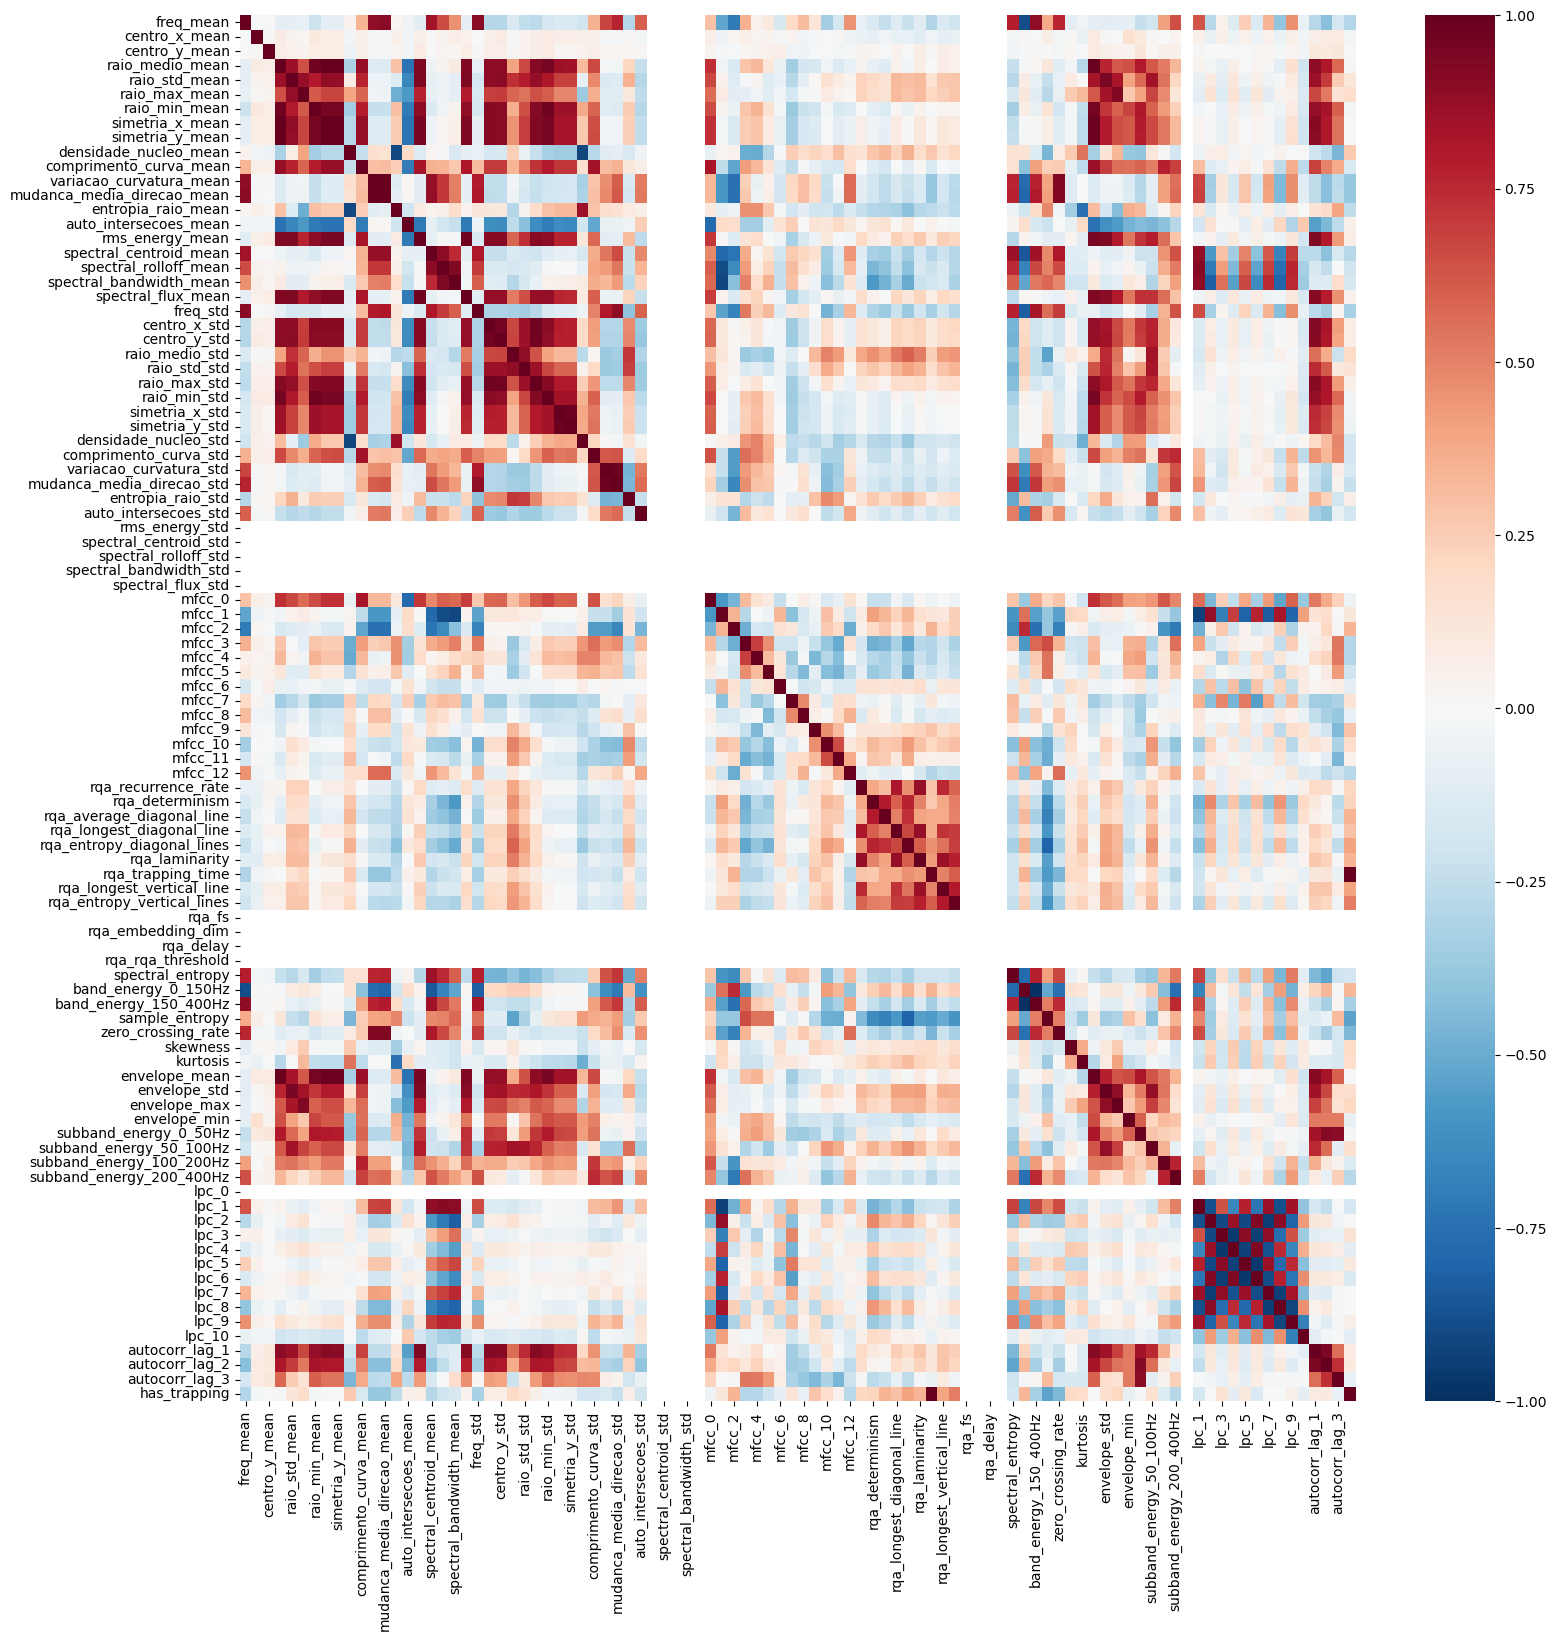

In [21]:
fig, ax = plt.subplots(figsize=(18, 18))

sns.heatmap(X_train_numeric.corr(),
            fmt='.2f',
            ax=ax,
            cmap="RdBu_r",
            vmin=-1,
            vmax=1)

O heatmap mostra claramente a existência de multicolinearidade, ou seja, grupos de features que estão fortemente correlacionadas entre si.

Manter features altamente correlacionadas é problemático por algumas razões:

- Redundância: O modelo não aprende nada de novo. Se duas features são 95% correlacionadas, elas estão essencialmente dizendo a mesma coisa.
- Instabilidade do Modelo: Alguns algoritmos (como regressões lineares) podem se tornar instáveis. Modelos de árvore (como o Random Forest) são mais robustos a isso, mas a redundância pode enviesar a interpretação da "importância das features".
- Maldição da Dimensionalidade: Manter features desnecessárias aumenta a complexidade do problema sem adicionar informação útil, podendo até piorar a performance do modelo.



In [22]:
print("1. Separando features numéricas e categóricas...")
numeric_cols = X_train_numeric.columns.tolist()
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']).columns.tolist()
print(
    f"Encontradas {len(numeric_cols)} features numéricas e {len(categorical_cols)} categóricas.")


print("\n2. Calculando a matriz de correlação...")
corr_matrix = X_train_numeric.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


print("\n3. Preparando dados para cálculo da Informação Mútua...")
X_train_encoded_for_mi = X_train.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_encoded_for_mi[col] = le.fit_transform(X_train_encoded_for_mi[col])

le_y = LabelEncoder()
y_train_encoded = le_y.fit_transform(y_train)

print("Calculando a Informação Mútua para todas as features...")
mi_scores = mutual_info_classif(
    X_train_encoded_for_mi, y_train_encoded, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns)


print("\n4. Identificando features redundantes para remover...")
threshold = 0.85
to_drop = set()  # Usar um set é mais eficiente para evitar duplicatas

for col in upper_triangle.columns:
    correlated_features = upper_triangle.index[upper_triangle[col] > threshold].tolist(
    )
    for row in correlated_features:
        if mi_series[row] < mi_series[col]:
            to_drop.add(row)
        else:
            to_drop.add(col)

to_drop = list(to_drop)

X_train_reduced = X_train.drop(columns=to_drop)
#X_test_reduced = X_test.drop(columns=to_drop)

print(
    f"\nNúmero de features removidas com critério de utilidade: {len(to_drop)}")
print("Features removidas:", sorted(to_drop))

1. Separando features numéricas e categóricas...
Encontradas 96 features numéricas e 2 categóricas.

2. Calculando a matriz de correlação...

3. Preparando dados para cálculo da Informação Mútua...
Calculando a Informação Mútua para todas as features...

4. Identificando features redundantes para remover...

Número de features removidas com critério de utilidade: 44
Features removidas: ['autocorr_lag_1', 'band_energy_0_150Hz', 'band_energy_150_400Hz', 'centro_y_std', 'comprimento_curva_mean', 'densidade_nucleo_std', 'entropia_raio_mean', 'envelope_mean', 'envelope_std', 'freq_mean', 'has_trapping', 'lpc_1', 'lpc_2', 'lpc_3', 'lpc_4', 'lpc_5', 'lpc_6', 'lpc_7', 'lpc_8', 'lpc_9', 'mudanca_media_direcao_mean', 'mudanca_media_direcao_std', 'raio_max_mean', 'raio_max_std', 'raio_medio_mean', 'raio_medio_std', 'raio_min_mean', 'raio_min_std', 'raio_std_mean', 'raio_std_std', 'rms_energy_mean', 'rqa_laminarity', 'rqa_longest_diagonal_line', 'rqa_longest_vertical_line', 'simetria_x_mean', 'sim

In [23]:
""" Outras colunas para remover que podem enviesar o modelo caso permaneçam como atributos"""
others_columns_to_remove = ['Gender', 'Location']
to_drop.extend(others_columns_to_remove)

In [24]:
to_drop

['envelope_std',
 'mudanca_media_direcao_mean',
 'raio_medio_mean',
 'band_energy_150_400Hz',
 'freq_mean',
 'simetria_x_mean',
 'subband_energy_50_100Hz',
 'lpc_5',
 'lpc_2',
 'lpc_1',
 'raio_min_std',
 'lpc_8',
 'spectral_bandwidth_mean',
 'autocorr_lag_1',
 'entropia_raio_mean',
 'band_energy_0_150Hz',
 'lpc_9',
 'rqa_longest_diagonal_line',
 'lpc_7',
 'spectral_rolloff_mean',
 'densidade_nucleo_std',
 'simetria_y_std',
 'mudanca_media_direcao_std',
 'subband_energy_0_50Hz',
 'rms_energy_mean',
 'variacao_curvatura_mean',
 'centro_y_std',
 'spectral_centroid_mean',
 'lpc_4',
 'spectral_flux_mean',
 'raio_min_mean',
 'comprimento_curva_mean',
 'rqa_longest_vertical_line',
 'lpc_6',
 'rqa_laminarity',
 'raio_std_mean',
 'lpc_3',
 'raio_max_std',
 'raio_medio_std',
 'simetria_y_mean',
 'envelope_mean',
 'has_trapping',
 'raio_max_mean',
 'raio_std_std',
 'Gender',
 'Location']

In [25]:
X_train_reduced = X_train_reduced.drop(columns=to_drop, errors='ignore')

<Axes: >

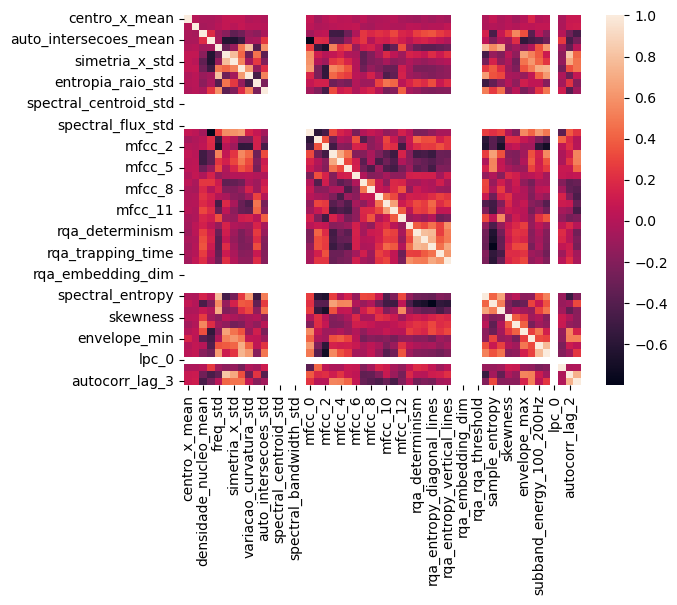

In [26]:
X_train_reduced = X_train_reduced.select_dtypes(include='number')
sns.heatmap(X_train_reduced.corr())

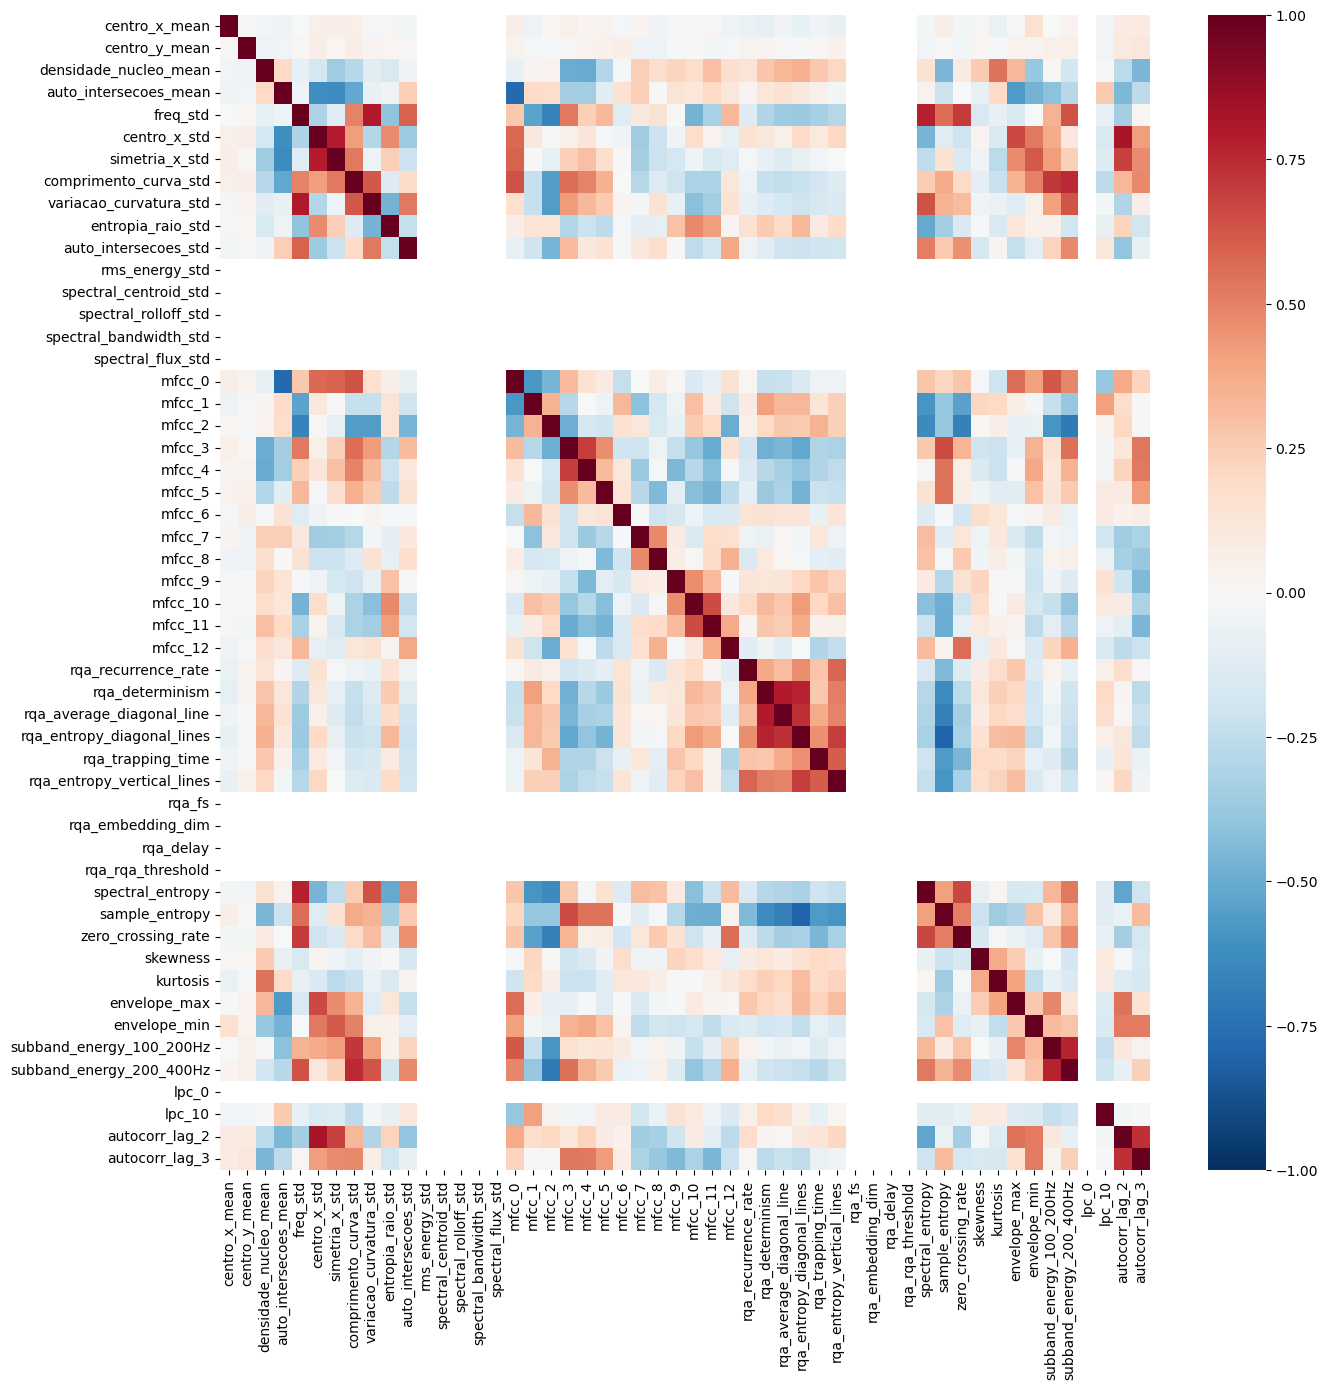

In [27]:

fig, ax = plt.subplots(figsize=(15, 15))

ax = sns.heatmap(X_train_reduced.corr(),
                 fmt='.2f',
                 ax=ax,
                 cmap="RdBu_r",
                 vmin=-1,
                 vmax=1,)
# sns.heatmap(X_train.corr())

In [59]:
# """ Correlograma das 30 principais"""
# top_vars = X_train_reduced.columns[:25].tolist()

# corr = X_train_reduced[top_vars].corr()

# plt.figure(figsize=(20, 10))


# sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", square=True)


# plt.title("Correlograma das 30 Variáveis com Maior Desvio Padrão")


# plt.tight_layout()


# plt.show()

### 3.2 Visualização da Distribuição por Classe

Para as features mais promissoras, é interessante criar gráficos que mostrem a distribuição dos valores para a classe Normal vs. Anormal. Se as distribuições forem bem diferentes, a feature é um bom preditor.

AVISO: Não foi possível calcular o KDE para 'rms_energy_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'spectral_centroid_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'spectral_rolloff_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'spectral_bandwidth_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'spectral_flux_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'rqa_delay'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'lpc_0'. Gerando novamente sem KDE.


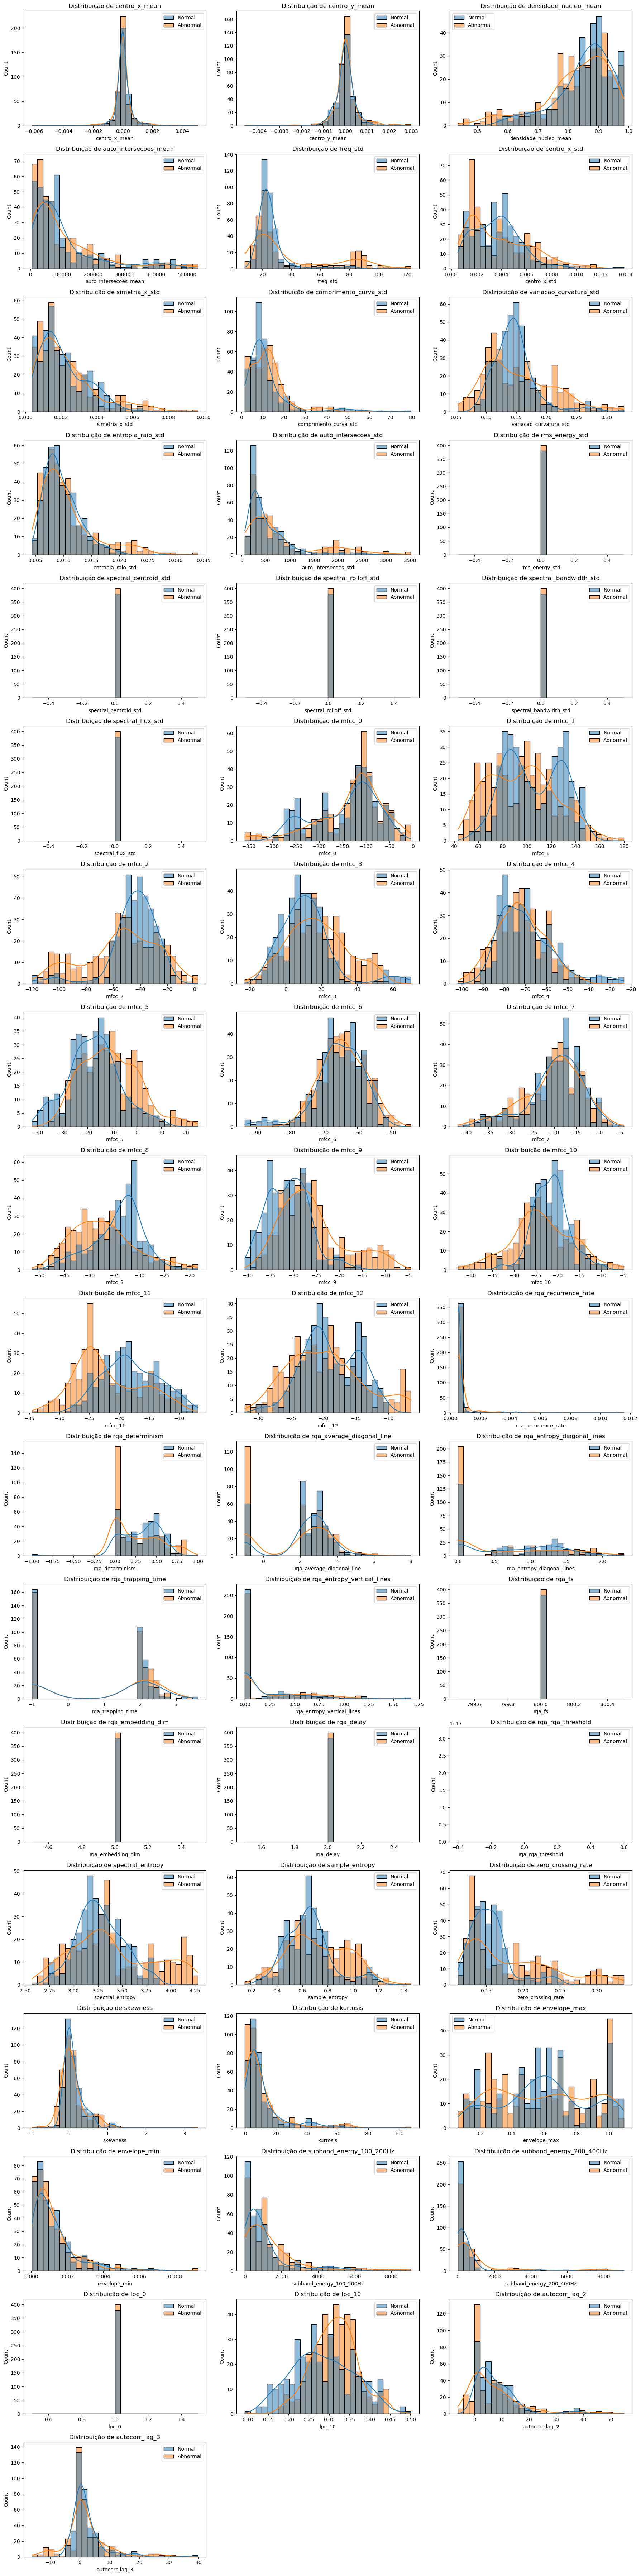

In [28]:

import math  

plot_df = X_train_reduced.join(y_train)
target_column_name = y_train.name

numeric_cols = X_train_reduced.select_dtypes(include=np.number).columns
n_features = len(numeric_cols)

ncols = 3  
nrows = math.ceil(n_features / ncols) 

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(ncols * 6, nrows * 4))

axes = axes.flatten()

for i, column in enumerate(numeric_cols):
    ax = axes[i]  

    try:
        sns.histplot(data=plot_df, x=column,
                     hue=target_column_name, kde=True, bins=30, ax=ax)
    except LinAlgError:
        print(f"AVISO: Não foi possível calcular o KDE para '{column}'. Gerando novamente sem KDE.")
        sns.histplot(data=plot_df, x=column,
                     hue=target_column_name, kde=False, bins=30, ax=ax)

    ax.set_title(f'Distribuição de {column}', fontsize=12)
    ax.legend_.set_title(None)  

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.grid(True)
plt.show()

Analisando e deletando as _features_ contínuas de valores constantes, pois não apresentam qualquer variabilidade.

In [29]:
cols_constantes = [
    col for col in X_train_reduced.columns if X_train_reduced[col].nunique() == 1]

print("Colunas com valor constante:", cols_constantes)


X_train_reduced = X_train_reduced.drop(columns=cols_constantes, errors='ignore')
# X_test_reduced = X_test_reduced.drop(
#     columns=cols_constantes, errors='ignore')

Colunas com valor constante: ['rms_energy_std', 'spectral_centroid_std', 'spectral_rolloff_std', 'spectral_bandwidth_std', 'spectral_flux_std', 'rqa_fs', 'rqa_embedding_dim', 'rqa_delay', 'rqa_rqa_threshold', 'lpc_0']


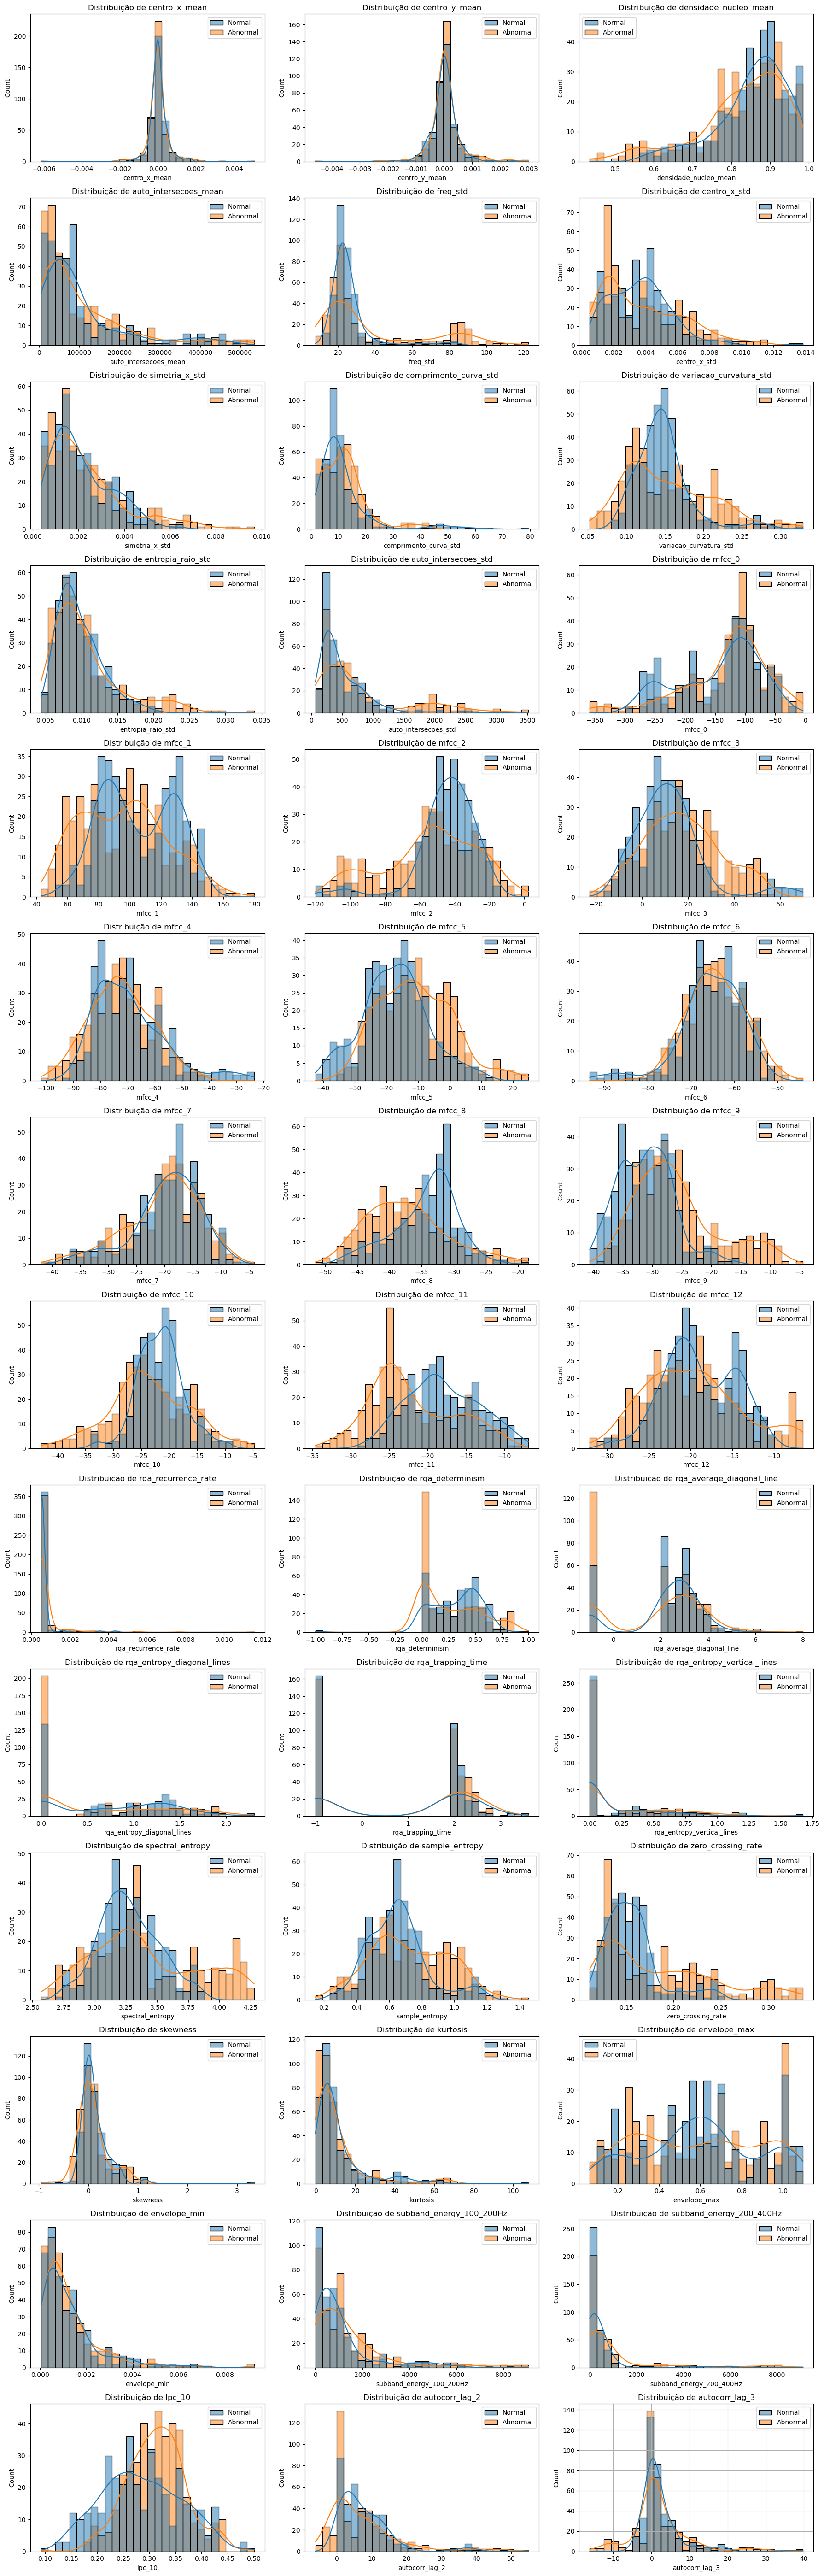

In [30]:
plot_df = X_train_reduced.join(y_train)
target_column_name = y_train.name

numeric_cols = X_train_reduced.select_dtypes(include=np.number).columns
n_features = len(numeric_cols)

ncols = 3
nrows = math.ceil(n_features / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(ncols * 6, nrows * 4))

axes = axes.flatten()

for i, column in enumerate(numeric_cols):
    ax = axes[i]

    try:
        sns.histplot(data=plot_df, x=column,
                     hue=target_column_name, kde=True, bins=30, ax=ax)
    except LinAlgError:
        print(
            f"AVISO: Não foi possível calcular o KDE para '{column}'. Gerando novamente sem KDE.")
        sns.histplot(data=plot_df, x=column,
                     hue=target_column_name, kde=False, bins=30, ax=ax)

    ax.set_title(f'Distribuição de {column}', fontsize=12)
    ax.legend_.set_title(None)

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.grid(True)
plt.show()

#### 3.3 Mutual Information

Medir quanto de informação uma feature contém sobre o rótulo (target), seja linear, não-linear, monotônica ou não.

Natureza: medida não-paramétrica de dependência estatística entre duas variáveis.

Interpretação:

- MI(X, Y) = 0 ⟺ X e Y são estatisticamente independentes.
- MI(X, Y) > 0 ⟺ há alguma relação informativa entre X e Y, linear ou não.

Estimamos o grau de dependência.

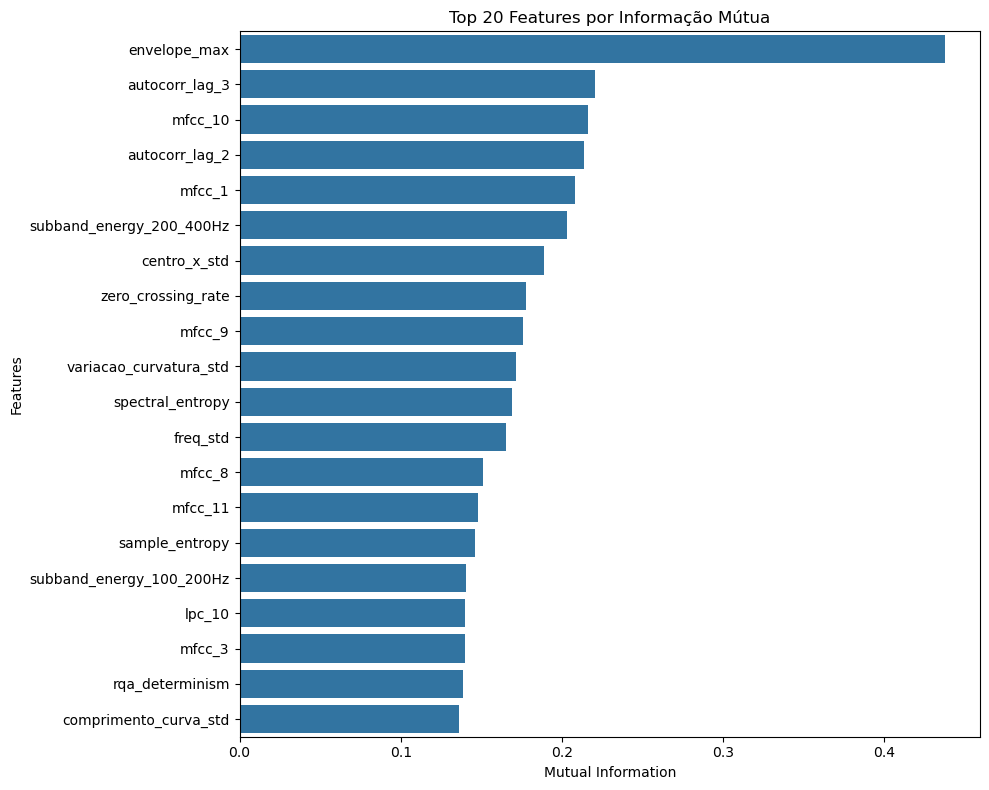

In [31]:

mi_scores = mutual_info_classif(X_train_reduced, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_reduced.columns, name="MI Score")
mi_series = mi_series.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series.head(20), y=mi_series.head(20).index)
plt.title("Top 20 Features por Informação Mútua")
plt.xlabel("Mutual Information")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### 3.4 Análise de Dimensionalidade

O objetivo é reduzir o número de dimensões para 2D ou 3D, preservando a estrutura de variabilidade dos dados, para:

- Visualizar separabilidade entre classes;
- Identificar clusters ou sobreposições;
- Detectar ruído ou _outliers_.

**Métodos**:

- **PCA (Principal Component Analysis)**
     - Linear: projeta os dados nos eixos que explicam mais variância.
     - Bom para compressão, interpretação e explicação.

- t-SNE (t-distributed Stochastic Neighbor Embedding)
     - Não linear, baseado em proximidade local entre pontos.
     - Excelente para visualização em 2D, mas não para modelagem nem generalização.



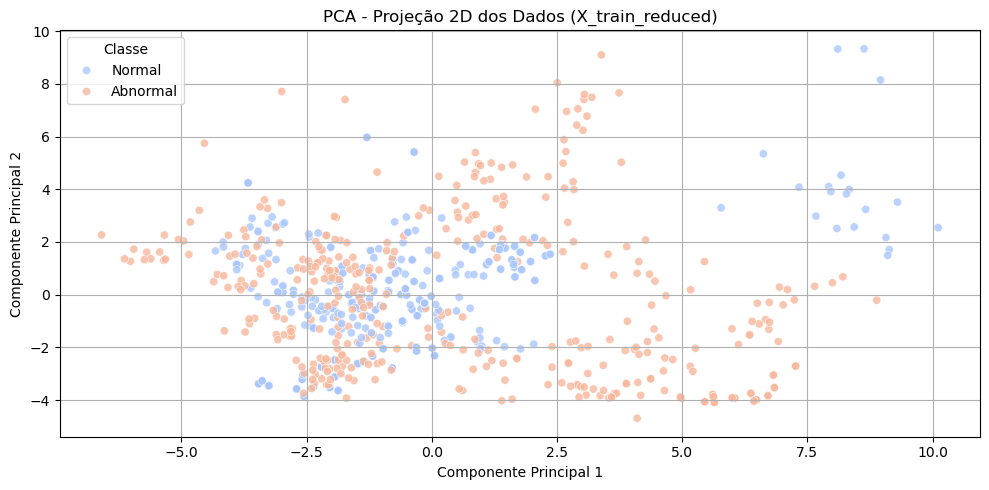

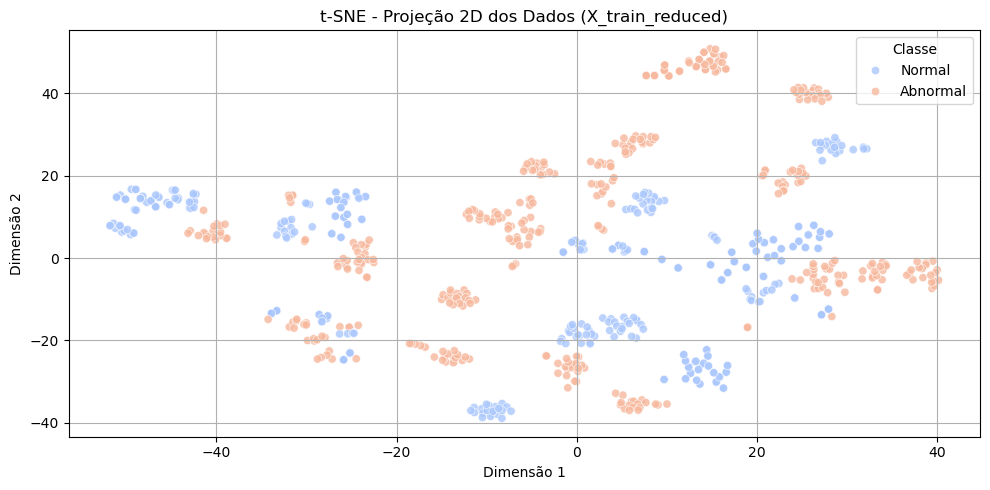

In [32]:
scaler = StandardScaler()  # Normalizando primeiro
X_scaled = scaler.fit_transform(X_train_reduced)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Classe"] = y_train.values

df_tsne = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])
df_tsne["Classe"] = y_train.values

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2",
                hue="Classe", palette="coolwarm", alpha=0.8)
plt.title("PCA - Projeção 2D dos Dados (X_train_reduced)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_tsne, x="Dim1", y="Dim2",
               hue="Classe", palette="coolwarm", alpha=0.8)
plt.title("t-SNE - Projeção 2D dos Dados (X_train_reduced)")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.grid(True)
plt.tight_layout()
plt.show()

O PCA está mostrando alguma estrutura, mas as duas primeiras componentes não são suficientes para separação clara. Isso pode indicar que a separação entre classes está em componentes menos dominantes (dimensões escondidas).

Com t-SNE, vemos _Clusters_ bem definidos localmente, com grupos puros de classe 1. A classe 0 forma pequenos núcleos bem separados. Então, o t-SNE favorece separação local, o que sugere que há padões fortes no espaço original, mesmo que não lineares. É uma boa indicação de que o modelo pode aprender bem com algoritmos baseados em proximidade, como _Random Forest_ ou MLP. E também é um bom sinal de que os atributos capturam relações não-lineares relevantes.

|                | **PCA**              | **t-SNE**                        |
| -------------- | ------------------------------- | ----------------------------------------- |
| Baseado em  | Variância global (retas, eixos) | Proximidade local (distância de vizinhos) |
| Objetivo    | Explicar o máximo com menos     | Mostrar grupos, clusters                  |
| Linear?     | Sim                             | Não                                       |
| Interpreta? | Sim (coeficientes, vetores)     | Não (é só visual)                         |


c:\Users\pflss\miniconda3\envs\sensory-translation\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


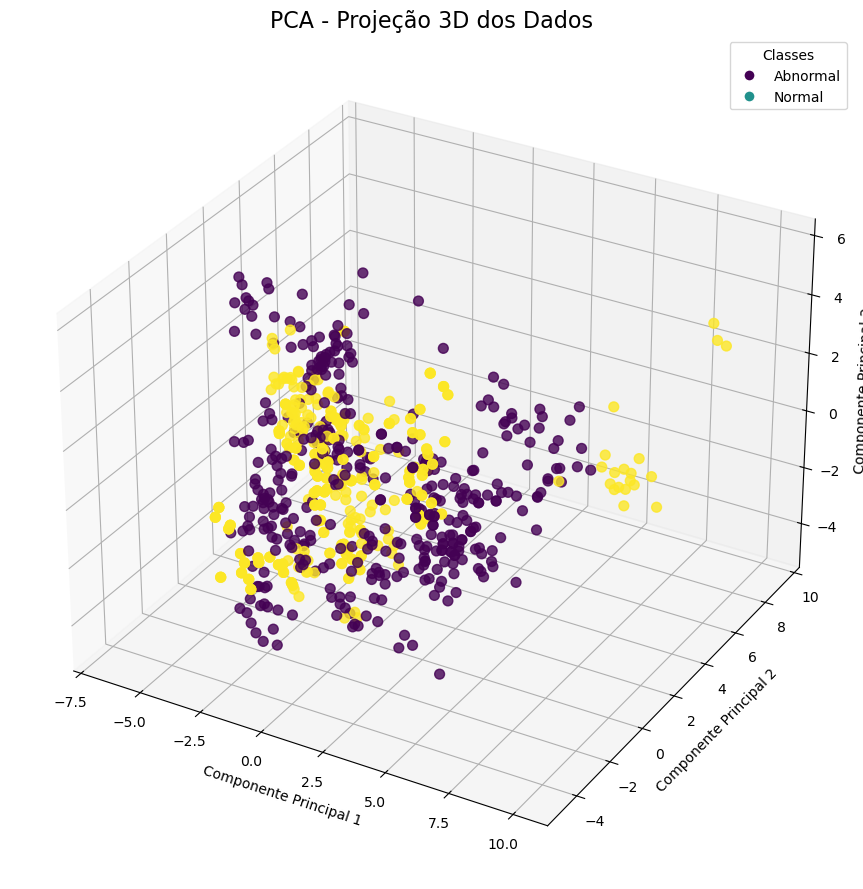

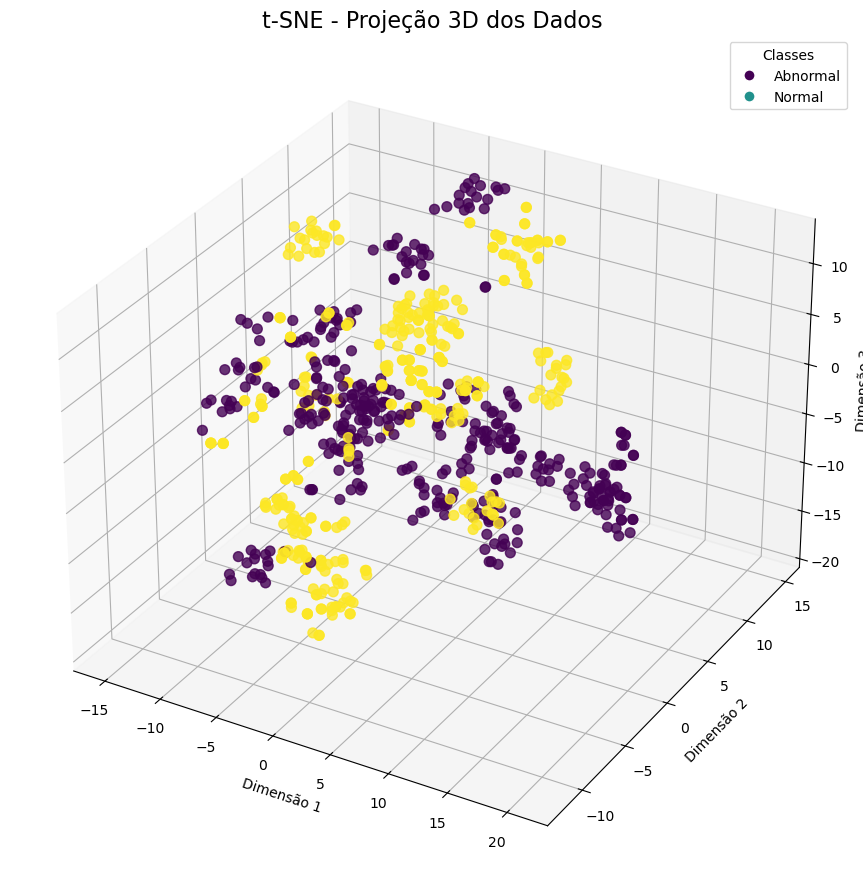

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_reduced.select_dtypes(include=np.number))


le = LabelEncoder()
y_encoded = le.fit_transform(y_train)


pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

tsne_3d = TSNE(n_components=3, random_state=42,
               perplexity=30, learning_rate=200, n_iter=1000)
X_tsne_3d = tsne_3d.fit_transform(X_scaled)


fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=y_encoded, cmap='viridis', alpha=0.8, s=50)  

ax.set_title("PCA - Projeção 3D dos Dados", fontsize=16)
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.set_zlabel("Componente Principal 3")

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=plt.cm.viridis(
                          i/len(le.classes_)),  # Pega a cor do cmap
                      markersize=8) for i in range(len(le.classes_))]
ax.legend(handles, le.classes_, title="Classes")

plt.tight_layout()
plt.show()


fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2],
                     c=y_encoded, cmap='viridis', alpha=0.8, s=50)

ax.set_title("t-SNE - Projeção 3D dos Dados", fontsize=16)
ax.set_xlabel("Dimensão 1")
ax.set_ylabel("Dimensão 2")
ax.set_zlabel("Dimensão 3")

ax.legend(handles, le.classes_, title="Classes")

plt.tight_layout()
plt.show()

### **Testando uma classificação simples**

In [30]:
cols_to_remove1 = to_drop.copy()
cols_to_remove2 = cols_constantes.copy()
cols_to_remove1.extend(cols_to_remove2)

Iniciando o treinamento do modelo multiclasse...

--- Resultados no Conjunto de Teste (Multiclasse) ---
              precision    recall  f1-score   support

    Abnormal       1.00      0.91      0.95       140
      Normal       0.82      1.00      0.90        60

    accuracy                           0.94       200
   macro avg       0.91      0.95      0.93       200
weighted avg       0.95      0.94      0.94       200


Gerando a Matriz de Confusão...


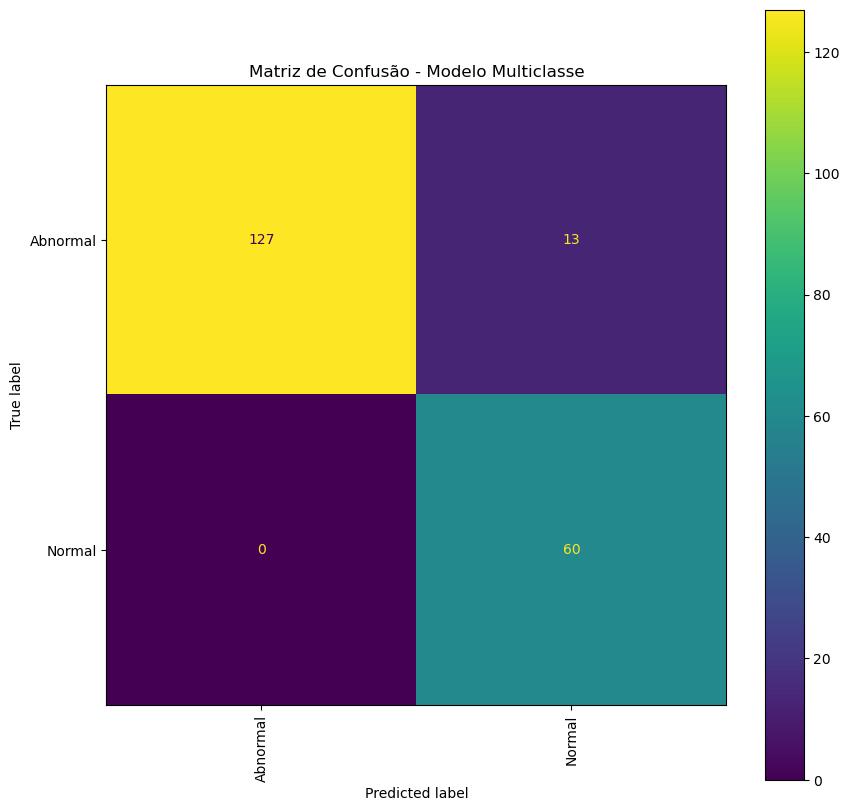

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

target_col = 'Heart Sound Type'

X_train = X_train.drop(columns=to_drop + cols_constantes, errors='ignore')
X_test = X_test.drop(columns=to_drop + cols_constantes, errors='ignore')

"""Pipeline de Pré-processamento prévio e simples, apenas para teste"""

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=['object', 'category']).columns.tolist()

if 'Heart Sound ID' in numeric_features:
    numeric_features.remove('Heart Sound ID')
if 'Heart Sound ID' in categorical_features:
    categorical_features.remove('Heart Sound ID')


"""
Transformador de colunas
"""
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Mantém colunas não especificadas (se houver)
)

""" 
criando o pipeline com o pré-processador e o classificador RandomForest
"""
model_multiclass = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

print("Iniciando o treinamento do modelo multiclasse...")
# O .fit() do pipeline lida com o y_train em formato de texto
model_multiclass.fit(X_train, y_train)

""" avaliando o modelo"""
print("\n--- Resultados no Conjunto de Teste (Multiclasse) ---")
y_pred = model_multiclass.predict(X_test)

print(classification_report(y_test, y_pred))

print("\nGerando a Matriz de Confusão...")
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, xticks_rotation='vertical')
plt.title("Matriz de Confusão - Modelo Multiclasse")
plt.show()

In [35]:
X_train.columns

Index(['centro_x_mean', 'centro_y_mean', 'densidade_nucleo_mean',
       'auto_intersecoes_mean', 'freq_std', 'centro_x_std', 'simetria_x_std',
       'comprimento_curva_std', 'variacao_curvatura_std', 'entropia_raio_std',
       'auto_intersecoes_std', 'mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3',
       'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10',
       'mfcc_11', 'mfcc_12', 'rqa_recurrence_rate', 'rqa_determinism',
       'rqa_average_diagonal_line', 'rqa_entropy_diagonal_lines',
       'rqa_trapping_time', 'rqa_entropy_vertical_lines', 'spectral_entropy',
       'sample_entropy', 'zero_crossing_rate', 'skewness', 'kurtosis',
       'envelope_max', 'envelope_min', 'subband_energy_100_200Hz',
       'subband_energy_200_400Hz', 'lpc_10', 'autocorr_lag_2',
       'autocorr_lag_3'],
      dtype='object')

In [36]:
X_copy = X.copy()
y_copy = y.copy()

In [37]:
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

y_train_copy = y_train.copy()
y_test_copy = y_test.copy()

In [38]:
X_copy = X_copy.drop(columns=['Heart Sound ID', 'Gender', 'Location'], errors='ignore')

In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

#cv = GroupKFold(n_splits=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model_multiclass, X_copy, y_copy, cv=cv, scoring='f1_macro')
print(f"F1 macro médio: {scores.mean():.4f} ± {scores.std():.4f}")


F1 macro médio: 0.9948 ± 0.0046


In [42]:
model_multiclass.fit(X_train_copy, y_train_copy)
importances = model_multiclass.named_steps['classifier'].feature_importances_
importances[:20]


array([0.0032056 , 0.005372  , 0.00929977, 0.02609759, 0.01680382,
       0.02281608, 0.01029696, 0.01908049, 0.01853992, 0.01415832,
       0.00995052, 0.01360718, 0.01801265, 0.04428566, 0.0187104 ,
       0.02405075, 0.02532507, 0.01390953, 0.01601451, 0.06825154])

In [41]:
X_copy.columns

Index(['freq_mean', 'centro_x_mean', 'centro_y_mean', 'raio_medio_mean',
       'raio_std_mean', 'raio_max_mean', 'raio_min_mean', 'simetria_x_mean',
       'simetria_y_mean', 'densidade_nucleo_mean', 'comprimento_curva_mean',
       'variacao_curvatura_mean', 'mudanca_media_direcao_mean',
       'entropia_raio_mean', 'auto_intersecoes_mean', 'rms_energy_mean',
       'spectral_centroid_mean', 'spectral_rolloff_mean',
       'spectral_bandwidth_mean', 'spectral_flux_mean', 'freq_std',
       'centro_x_std', 'centro_y_std', 'raio_medio_std', 'raio_std_std',
       'raio_max_std', 'raio_min_std', 'simetria_x_std', 'simetria_y_std',
       'densidade_nucleo_std', 'comprimento_curva_std',
       'variacao_curvatura_std', 'mudanca_media_direcao_std',
       'entropia_raio_std', 'auto_intersecoes_std', 'rms_energy_std',
       'spectral_centroid_std', 'spectral_rolloff_std',
       'spectral_bandwidth_std', 'spectral_flux_std', 'mfcc_0', 'mfcc_1',
       'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5